# 01 - Exploration, préparation des données et feature engineering

Projet : **Prêt à dépenser - Home Credit Default Risk**

Objectifs de ce notebook :

- charger les fichiers Kaggle ;
- analyser la variable cible `TARGET` ;
- vérifier les doublons et les valeurs manquantes ;
- fusionner les tables avec `SK_ID_CURR` et `SK_ID_BUREAU` ;
- créer un dataset final enrichi ;
- exporter un fichier propre pour la modélisation.

> Important : les fichiers CSV Kaggle doivent être placés dans `data/raw/` à la racine du projet.


In [1]:
from pathlib import Path
import os
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == 'notebooks' else CURRENT_DIR
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Racine projet :', PROJECT_ROOT)
print('Dossier data/raw :', RAW_DIR)
print('Existe :', RAW_DIR.exists())

Racine projet : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring
Dossier data/raw : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\data\raw
Existe : True


## 1. Fonctions utilitaires

Les fichiers Kaggle peuvent parfois être enregistrés avec une double extension sur Windows (`.csv.csv`). La fonction `find_csv` permet de charger un fichier même si son nom exact varie légèrement.


In [2]:
def find_csv(filename: str) -> Path:
    # Retourne le chemin d'un fichier CSV dans data/raw.
    # Accepte filename, filename.csv et filename.csv.csv pour éviter les erreurs Windows.
    candidates = [
        RAW_DIR / filename,
        RAW_DIR / f"{filename}.csv" if not filename.endswith('.csv') else RAW_DIR / filename,
        RAW_DIR / f"{filename}.csv.csv" if not filename.endswith('.csv.csv') else RAW_DIR / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Fichier introuvable pour {filename}. Vérifie le dossier {RAW_DIR} et les extensions."
    )


def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    # Nettoie les noms de colonnes pour éviter les erreurs LightGBM/JSON.
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in df.columns]
    counts = {}
    new_cols = []
    for col in df.columns:
        if col not in counts:
            counts[col] = 0
            new_cols.append(col)
        else:
            counts[col] += 1
            new_cols.append(f"{col}_{counts[col]}")
    df.columns = new_cols
    return df


def one_hot_encoder(df: pd.DataFrame, nan_as_category: bool = True):
    # Encode les variables catégorielles en variables indicatrices.
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns


def missing_values_table(df: pd.DataFrame) -> pd.DataFrame:
    # Tableau synthétique des valeurs manquantes.
    mis_val = df.isna().sum()
    mis_val_percent = 100 * mis_val / len(df)
    table = pd.concat([mis_val, mis_val_percent], axis=1)
    table = table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
    table = table[table['Missing Values'] > 0].sort_values('% of Total Values', ascending=False)
    return table


## 2. Chargement des données principales

`application_train.csv` contient la cible `TARGET` :

- `0` : client qui rembourse correctement ;
- `1` : client avec difficulté de remboursement.


In [3]:
app_train = pd.read_csv(find_csv('application_train.csv'))
app_test = pd.read_csv(find_csv('application_test.csv'))

print('application_train :', app_train.shape)
print('application_test  :', app_test.shape)
app_train.head()

application_train : (307511, 122)
application_test  : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,...,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,...,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,...,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.

In [4]:
print('Doublons SK_ID_CURR train :', app_train['SK_ID_CURR'].duplicated().sum())
print('Doublons SK_ID_CURR test  :', app_test['SK_ID_CURR'].duplicated().sum())
print('Distribution de TARGET :')
display(app_train['TARGET'].value_counts())
display(app_train['TARGET'].value_counts(normalize=True).rename('proportion'))

Doublons SK_ID_CURR train : 0
Doublons SK_ID_CURR test  : 0
Distribution de TARGET :


TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

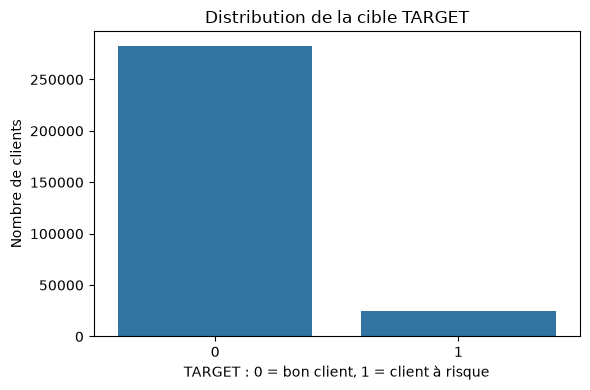

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=app_train)
plt.title('Distribution de la cible TARGET')
plt.xlabel('TARGET : 0 = bon client, 1 = client à risque')
plt.ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

### Analyse métier

La classe `1` est minoritaire. Le projet est donc un problème de **classification déséquilibrée**. Il faudra utiliser des métriques adaptées comme l'AUC, le recall et surtout le score métier qui pénalise davantage les faux négatifs.


In [6]:
missing_train = missing_values_table(app_train)
missing_train.head(20)

,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


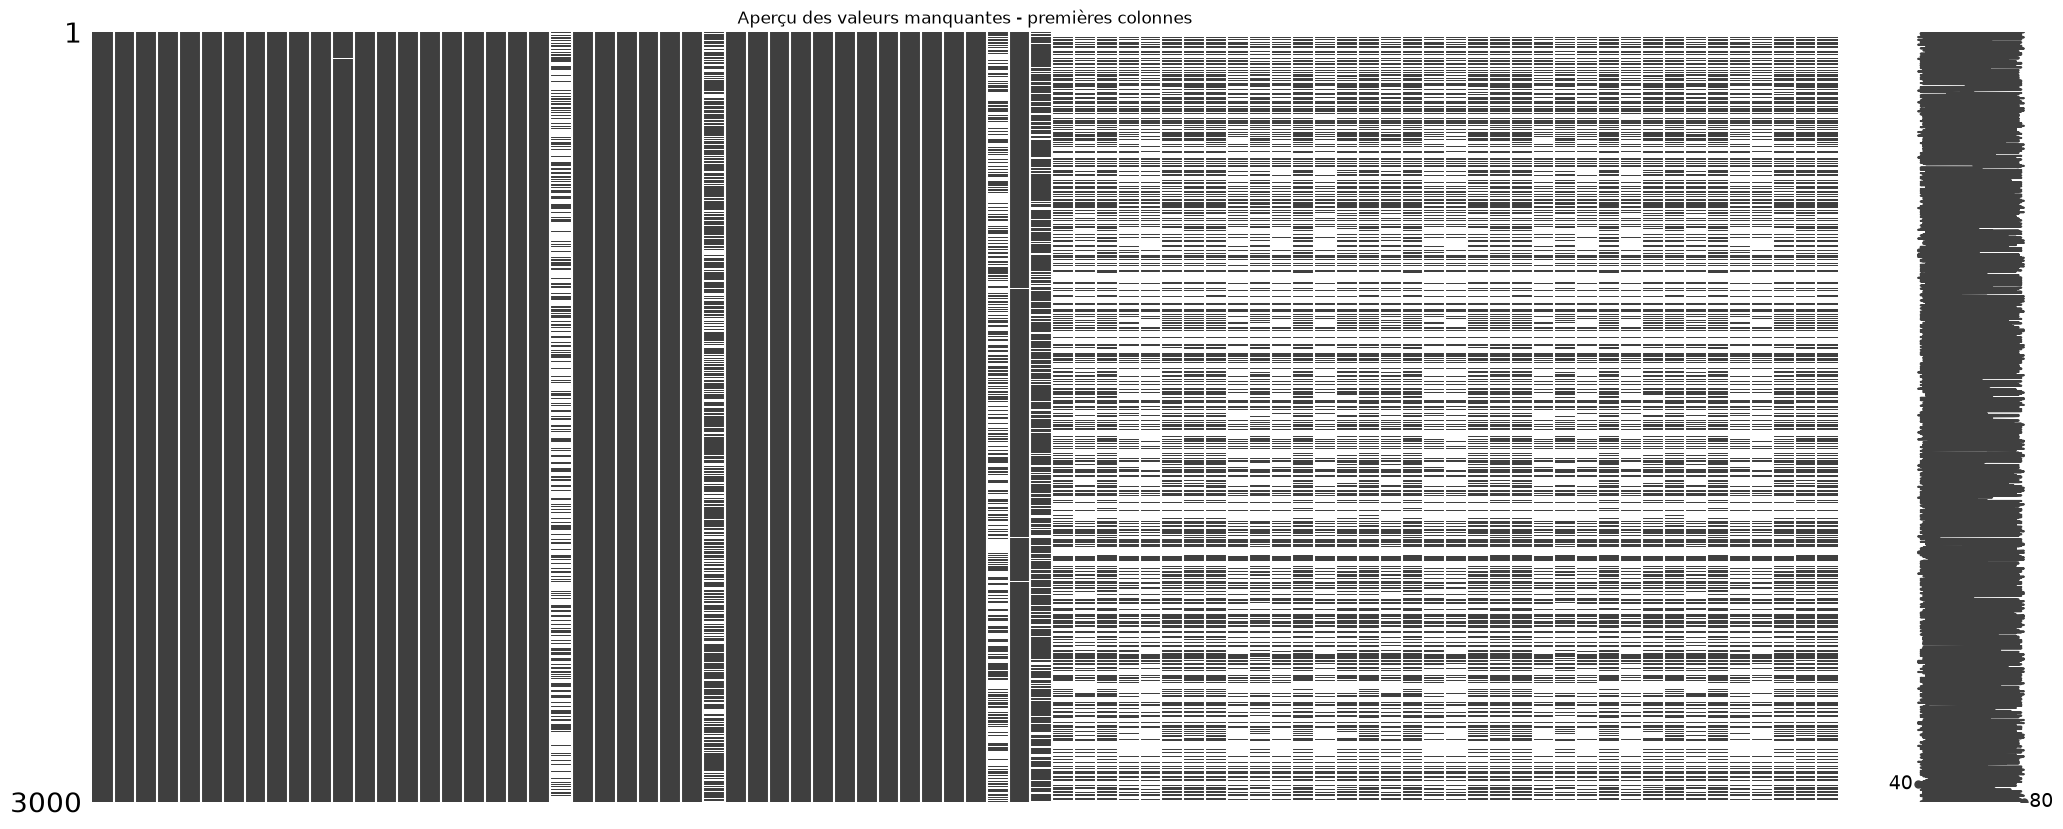

In [7]:
sample_missing = app_train.sample(n=min(3000, len(app_train)), random_state=42)
msno.matrix(sample_missing.iloc[:, :80])
plt.title('Aperçu des valeurs manquantes - premières colonnes')
plt.show()

## 3. Préparation de la table principale

On combine les données train et test pour appliquer les mêmes transformations, puis on sépare à nouveau à la fin.


In [8]:
n_train = app_train.shape[0]
y = app_train['TARGET'].copy()

app_test['TARGET'] = np.nan
app = pd.concat([app_train, app_test], axis=0, ignore_index=True)

app['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

app['CREDIT_INCOME_PERCENT'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL']
app['ANNUITY_INCOME_PERCENT'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['CREDIT_TERM'] = app['AMT_ANNUITY'] / app['AMT_CREDIT']
app['DAYS_EMPLOYED_PERCENT'] = app['DAYS_EMPLOYED'] / app['DAYS_BIRTH']

app, app_cat_cols = one_hot_encoder(app)
print('Shape après encodage application :', app.shape)
app.head()

Shape après encodage application : (356255, 266)


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,...,ORGANIZATION_TYPE_Industry: type 2,ORGANIZATION_TYPE_Industry: type 3,ORGANIZATION_TYPE_Industry: type 4,ORGANIZATION_TYPE_Industry: type 5,ORGANIZATION_TYPE_Industry: type 6,ORGANIZATION_TYPE_Industry: type 7,ORGANIZATION_TYPE_Industry: type 8,ORGANIZATION_TYPE_Industry: type 9,ORGANIZATION_TYPE_Insurance,ORGANIZATION_TYPE_Kindergarten,ORGANIZATION_TYPE_Legal Services,ORGANIZATION_TYPE_Medicine,ORGANIZATION_TYPE_Military,ORGANIZATION_TYPE_Mobile,ORGANIZATION_TYPE_Other,ORGANIZATION_TYPE_Police,ORGANIZATION_TYPE_Postal,ORGANIZATION_TYPE_Realtor,ORGANIZATION_TYPE_Religion,ORGANIZATION_TYPE_Restaurant,ORGANIZATION_TYPE_School,ORGANIZATION_TYPE_Security,ORGANIZATION_TYPE_Security Ministries,ORGANIZATION_TYPE_Self-employed,ORGANIZATION_TYPE_Services,ORGANIZATION_TYPE_Telecom,ORGANIZATION_TYPE_Trade: type 1,ORGANIZATION_TYPE_Trade: type 2,ORGANIZATION_TYPE_Trade: type 3,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA,ORGANIZATION_TYPE_nan,FONDKAPREMONT_MODE_not specified,FONDKAPREMONT_MODE_org spec account,FONDKAPREMONT_MODE_reg oper account,FONDKAPREMONT_MODE_reg oper spec account,FONDKAPREMONT_MODE_nan,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,HOUSETYPE_MODE_nan,WALLSMATERIAL_MODE_Block,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Wooden,WALLSMATERIAL_MODE_nan,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,EMERGENCYSTATE_MODE_nan
0,100002,1.0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,1.0,2,2,10,0,0,0,0,0,0,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False
1,100003,0.0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,-1186.0,-291,NaN,1,1,0,1,1,0,2.0,1,1,11,0,0,0,0,0,0,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,

## 4. Jointure de `bureau` et `bureau_balance`

`bureau.csv` contient les crédits précédents du client dans d'autres institutions. `bureau_balance.csv` contient l'historique mensuel de ces crédits.


In [9]:
try:
    bureau = pd.read_csv(find_csv('bureau.csv'))
    bureau_balance = pd.read_csv(find_csv('bureau_balance.csv'))
    print('bureau :', bureau.shape)
    print('bureau_balance :', bureau_balance.shape)

    bureau_balance, bb_cat = one_hot_encoder(bureau_balance)
    bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(['min', 'max', 'mean', 'size'])
    bb_agg.columns = ['BB_' + '_'.join(col).upper() for col in bb_agg.columns.values]
    bb_agg.reset_index(inplace=True)

    bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
    bureau, bureau_cat = one_hot_encoder(bureau)

    bureau_num_cols = [c for c in bureau.columns if c not in ['SK_ID_CURR', 'SK_ID_BUREAU']]
    bureau_agg = bureau.groupby('SK_ID_CURR')[bureau_num_cols].agg(['min', 'max', 'mean', 'sum'])
    bureau_agg.columns = ['BURO_' + '_'.join(col).upper() for col in bureau_agg.columns.values]
    bureau_agg.reset_index(inplace=True)

    app = app.merge(bureau_agg, on='SK_ID_CURR', how='left')
    print('Shape après bureau :', app.shape)

    del bureau, bureau_balance, bb_agg, bureau_agg
    gc.collect()
except FileNotFoundError as e:
    print('Tables bureau non trouvées :', e)

bureau : (1716428, 17)
bureau_balance : (27299925, 3)
Shape après bureau : (356255, 702)


## 5. Jointure de `previous_application`

Cette table contient les anciennes demandes de crédit du client. Elle apporte des informations importantes sur l'historique du comportement de demande.


In [10]:
try:
    previous = pd.read_csv(find_csv('previous_application.csv'))
    print('previous_application :', previous.shape)

    previous.replace(365243, np.nan, inplace=True)
    previous, prev_cat = one_hot_encoder(previous)

    prev_num_cols = [c for c in previous.columns if c not in ['SK_ID_CURR', 'SK_ID_PREV']]
    prev_agg = previous.groupby('SK_ID_CURR')[prev_num_cols].agg(['min', 'max', 'mean', 'sum'])
    prev_agg.columns = ['PREV_' + '_'.join(col).upper() for col in prev_agg.columns.values]
    prev_agg.reset_index(inplace=True)

    app = app.merge(prev_agg, on='SK_ID_CURR', how='left')
    print('Shape après previous_application :', app.shape)

    del previous, prev_agg
    gc.collect()
except FileNotFoundError as e:
    print('Table previous_application non trouvée :', e)

previous_application : (1670214, 37)
Shape après previous_application : (356255, 1414)


## 6. Jointure des tables de suivi de paiement

On agrège les tables `POS_CASH_balance`, `installments_payments` et `credit_card_balance` au niveau client.


In [11]:
secondary_tables = {
    'POS': 'POS_CASH_balance.csv',
    'INST': 'installments_payments.csv',
    'CC': 'credit_card_balance.csv'
}

for prefix, filename in secondary_tables.items():
    try:
        df_sec = pd.read_csv(find_csv(filename))
        print(prefix, df_sec.shape)
        df_sec, _ = one_hot_encoder(df_sec)
        id_cols = [c for c in ['SK_ID_CURR', 'SK_ID_PREV'] if c in df_sec.columns]
        feature_cols = [c for c in df_sec.columns if c not in id_cols]
        agg = df_sec.groupby('SK_ID_CURR')[feature_cols].agg(['min', 'max', 'mean', 'sum'])
        agg.columns = [prefix + '_' + '_'.join(col).upper() for col in agg.columns.values]
        agg.reset_index(inplace=True)
        app = app.merge(agg, on='SK_ID_CURR', how='left')
        print('Shape après', prefix, ':', app.shape)
        del df_sec, agg
        gc.collect()
    except FileNotFoundError as e:
        print('Table non trouvée :', filename, '-', e)

POS (10001358, 8)
Shape après POS : (356255, 1474)
INST (13605401, 8)
Shape après INST : (356255, 1498)
CC (3840312, 23)
Shape après CC : (356255, 1610)


## 7. Nettoyage final et export

On nettoie les noms de colonnes, on remplace les valeurs infinies, puis on exporte le dataset final.


In [12]:
app = clean_column_names(app)
app = app.replace([np.inf, -np.inf], np.nan)

train_processed = app[app['TARGET'].notna()].copy()
test_processed = app[app['TARGET'].isna()].copy()

train_processed['TARGET'] = train_processed['TARGET'].astype(int)

print('Train final :', train_processed.shape)
print('Test final  :', test_processed.shape)
print('Nombre total de variables explicatives :', train_processed.drop(columns=['TARGET']).shape[1])

Train final : (307511, 1610)
Test final  : (48744, 1610)
Nombre total de variables explicatives : 1609


In [13]:
train_path = PROCESSED_DIR / 'home_credit_train_processed.csv'
test_path = PROCESSED_DIR / 'home_credit_test_processed.csv'

train_processed.to_csv(train_path, index=False)
test_processed.to_csv(test_path, index=False)

print('Fichier train sauvegardé :', train_path)
print('Fichier test sauvegardé  :', test_path)

Fichier train sauvegardé : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\data\processed\home_credit_train_processed.csv
Fichier test sauvegardé  : C:\Users\ajarl\Documents\projet_6_Initiez_vous_au_MLOPS\pret_a_depenser_scoring\data\processed\home_credit_test_processed.csv


## Conclusion du notebook 1

Le dataset final est propre, fusionné et enrichi. Il est prêt pour l'entraînement des modèles dans le notebook 2.

Points importants :

- les données proviennent de plusieurs tables liées par `SK_ID_CURR` et `SK_ID_BUREAU` ;
- la cible est déséquilibrée ;
- les variables catégorielles ont été encodées ;
- les valeurs manquantes sont conservées pour être imputées ou gérées par les modèles ;
- les noms de colonnes sont nettoyés pour éviter les erreurs LightGBM.
